# Hierarchy saliency maps: from a min-tree to graph edges

This executable guide introduces Cousty-style hierarchy saliency. Its central example extends a slide image to a $3\times3$ 4-connected grid, adding a second regional minimum.

**Central result.** Given a connected hierarchy and a compatible valuation, the formal map is indexed by image-graph edges. For the example min-tree, LCA projection and the MST minimax route give the same values.

Four related objects remain distinct:

1. the formal edge map $\Phi(H)$;
2. $\Psi(w)=\Phi(\operatorname{QFZ}(G,w))$ from arbitrary edge weights;
3. the raster `contourMap` visualization;
4. Xu shape-space saliency.

Main reference: Jean Cousty, Laurent Najman, Yukiko Kenmochi, and Silvio Guimarães, [Hierarchical Segmentations with Graphs: Quasi-flat Zones, Minimum Spanning Trees, and Saliency Maps](https://doi.org/10.1007/s10851-017-0768-7), *Journal of Mathematical Imaging and Vision* 60(4), 479–502, 2018. The complete code-to-paper mapping is in [`docs/saliency.md`](../docs/saliency.md#primary-references-and-implementation-correspondence).

## Goal and notation

Let $f:E\rightarrow V$ be an image, $G=(E,\mathcal A)$ its adjacency graph, and $H$ a connected hierarchy. Pixel $p$ has direct owner $\operatorname{owner}(p)$. A compatible valuation grows toward the root:

\[
v(\operatorname{parent}(u))\geq v(u).
\]

Under the direct convention, a transition edge receives

\[
\Phi(H)(p,q)=v\!\left(\operatorname{LCA}(\operatorname{owner}(p),\operatorname{owner}(q))\right).
\]

Same-owner edges receive zero. With positive partition-appearance levels, Cousty's convention writes `level(LCA) - 1`. The formal map is a function on graph edges, not a pixel-score image.

## Setup

The installed package is imported directly. Prepare the notebook environment outside the notebook as described in `README.md`.

In [1]:
from __future__ import annotations

import mmcfilters
from matplotlib import colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

np.set_printoptions(suppress=True)
print(f"mmcfilters: {mmcfilters.__version__}")


mmcfilters: 3.0.1.post41


## 1. A $3\times3$ image and its 4-connected graph

We use

\[
f=\begin{bmatrix}5&3&5\\1&2&4\\4&1&3\end{bmatrix}.
\]

Pixel $p_8=1$ creates a second regional minimum. It remains separate from $p_4=1$ at level 1 and merges at level 2. Assign every edge

\[
w(p,q)=\max\{f(p),f(q)\}.
\]

Then $w(p,q)\leq\lambda$ exactly when both endpoints belong to the lower-level set at $\lambda$.

,aresta,"w=max(f(p),f(q))"
0,p1—p2,5
1,p1—p4,5
2,p2—p3,5
3,p2—p5,3
4,p3—p6,5
5,p4—p5,2
6,p4—p7,4
7,p5—p6,4
8,p5—p8,2
9,p6—p9,4


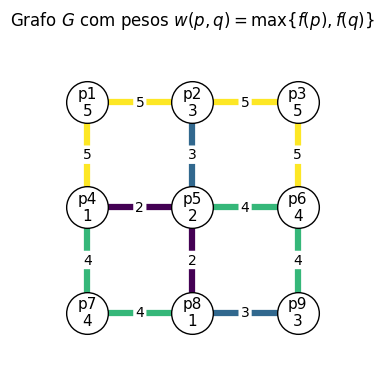

In [2]:
image = np.ascontiguousarray(
    [
        [5, 3, 5],
        [1, 2, 4],
        [4, 1, 3],
    ],
    dtype=np.uint8,
)
num_rows, num_cols = image.shape


def pixel_name(pixel_id):
    return f"p{int(pixel_id) + 1}"


def grid_edges_4(rows, cols):
    edges = []
    for row in range(rows):
        for col in range(cols):
            source = row * cols + col
            if col + 1 < cols:
                edges.append((source, source + 1))
            if row + 1 < rows:
                edges.append((source, source + cols))
    return edges


def edge_lookup(edge_map):
    return {
        tuple(sorted((int(source), int(target)))): float(value)
        for source, target, value in zip(
            edge_map["sources"],
            edge_map["targets"],
            edge_map["values"],
        )
    }


def plot_edge_values(base_image, edges, values, title, emphasized=None):
    rows, cols = base_image.shape
    emphasized = None if emphasized is None else {
        tuple(sorted(edge)) for edge in emphasized
    }
    values = np.asarray(values, dtype=np.float64)
    value_min = float(values.min()) if values.size else 0.0
    value_max = float(values.max()) if values.size else 1.0
    if value_max <= value_min:
        value_max = value_min + 1.0
    norm = colors.Normalize(vmin=value_min, vmax=value_max)
    cmap = plt.get_cmap("viridis")

    fig, axis = plt.subplots(figsize=(6.2, 3.8), constrained_layout=True)
    for (source, target), value in zip(edges, values):
        source_row, source_col = divmod(source, cols)
        target_row, target_col = divmod(target, cols)
        pair = tuple(sorted((source, target)))
        selected = emphasized is None or pair in emphasized
        axis.plot(
            [source_col, target_col],
            [source_row, target_row],
            color=cmap(norm(value)) if selected else "0.82",
            linewidth=4.5 if selected else 1.5,
            alpha=1.0 if selected else 0.65,
            zorder=1,
        )
        axis.text(
            (source_col + target_col) / 2,
            (source_row + target_row) / 2,
            f"{value:g}",
            ha="center",
            va="center",
            fontsize=10,
            bbox={"boxstyle": "round,pad=0.16", "fc": "white", "ec": "none"},
            zorder=3,
        )

    for pixel_id, value in enumerate(base_image.ravel()):
        row, col = divmod(pixel_id, cols)
        axis.scatter(col, row, s=900, color="white", edgecolor="black", zorder=2)
        axis.text(
            col,
            row,
            f"{pixel_name(pixel_id)}\n{int(value)}",
            ha="center",
            va="center",
            fontsize=11,
            zorder=4,
        )
    axis.set_title(title)
    axis.set_xlim(-0.65, cols - 0.35)
    axis.set_ylim(rows - 0.35, -0.65)
    axis.set_aspect("equal")
    axis.axis("off")
    plt.show()


graph_edges = grid_edges_4(num_rows, num_cols)
flat_image = image.ravel()
edge_weights = [
    int(max(flat_image[source], flat_image[target]))
    for source, target in graph_edges
]

edge_weight_frame = pd.DataFrame(
    {
        "aresta": [
            f"{pixel_name(source)}—{pixel_name(target)}"
            for source, target in graph_edges
        ],
        "w=max(f(p),f(q))": edge_weights,
    }
)
display(edge_weight_frame)
plot_edge_values(
    image,
    graph_edges,
    edge_weights,
    r"Graph $G$ with weights $w(p,q)=\max\{f(p),f(q)\}$",
)


### 1.1 Quasi-flat zones

At threshold $\lambda$, retain edges with $w\leq\lambda$. Their connected components form $\operatorname{QFZ}_\lambda(G,w)$. Components only merge as the threshold increases.

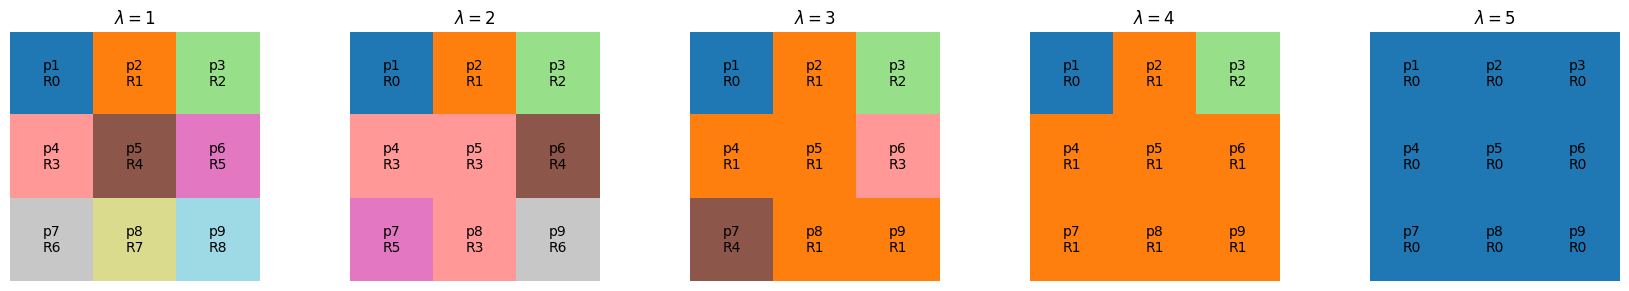

In [3]:
class DisjointSet:
    def __init__(self, size):
        self.parent = list(range(size))
        self.size = [1] * size

    def find(self, item):
        while self.parent[item] != item:
            self.parent[item] = self.parent[self.parent[item]]
            item = self.parent[item]
        return item

    def unite(self, first, second):
        first = self.find(first)
        second = self.find(second)
        if first == second:
            return False
        if self.size[first] < self.size[second]:
            first, second = second, first
        self.parent[second] = first
        self.size[first] += self.size[second]
        return True


def qfz_labels(num_vertices, edges, weights, threshold):
    components = DisjointSet(num_vertices)
    for (source, target), weight in zip(edges, weights):
        if weight <= threshold:
            components.unite(source, target)
    root_to_label = {}
    labels = []
    for vertex in range(num_vertices):
        root = components.find(vertex)
        root_to_label.setdefault(root, len(root_to_label))
        labels.append(root_to_label[root])
    return np.asarray(labels, dtype=np.int32)


qfz_levels = sorted({int(image.min()), *edge_weights})
fig, axes = plt.subplots(
    1,
    len(qfz_levels),
    figsize=(3.4 * len(qfz_levels), 2.8),
    constrained_layout=True,
)
for axis, level in zip(axes, qfz_levels):
    labels = qfz_labels(image.size, graph_edges, edge_weights, level)
    axis.imshow(
        labels.reshape(image.shape),
        cmap="tab20",
        interpolation="nearest",
        vmin=0,
        vmax=image.size - 1,
    )
    for pixel_id, label in enumerate(labels):
        row, col = divmod(pixel_id, num_cols)
        axis.text(col, row, f"{pixel_name(pixel_id)}\nR{label}", ha="center", va="center")
    axis.set_title(rf"$\lambda={level}$")
    axis.axis("off")
plt.show()


## 2. Route A — min-tree $\rightarrow$ LCA $\rightarrow$ saliency

The min-tree organizes connected lower-level components. The two minima merge in the altitude-2 node, making both LCA and extinction non-trivial. Pixels entering at each level are node proper parts.

A component tree is originally a hierarchy of partial partitions. The API completes it with direct-proper-part atoms before graph projection.

In [4]:
min_tree = mmcfilters.MorphologicalTreeFactory.createMinTree(
    image,
    radius=1.0,
)

min_altitude = np.zeros(min_tree.numInternalNodeSlots, dtype=np.float32)
min_tree_rows = []
for node_id in min_tree.getAliveNodeIds():
    node_id = int(node_id)
    min_altitude[node_id] = float(min_tree.getAltitude(node_id))
    min_tree_rows.append(
        {
            "node": node_id,
            "parent": int(min_tree.getNodeParent(node_id)),
            "altitude": int(min_tree.getAltitude(node_id)),
            "proper parts": [
                pixel_name(pixel_id)
                for pixel_id in min_tree.getProperParts(node_id)
            ],
            "suporte": [
                pixel_name(pixel_id)
                for pixel_id in min_tree.getConnectedComponent(node_id)
            ],
        }
    )

min_tree_frame = pd.DataFrame(min_tree_rows).sort_values("altitude")
display(min_tree_frame)
print("root:", min_tree.getRoot())
print("folhas:", min_tree.getLeafNodeIds())


,node,parent,altitude,proper parts,suporte
4,4,3,1,[p4],[p4]
5,5,3,1,[p8],[p8]
3,3,2,2,[p5],"[p5, p4, p8]"
2,2,1,3,"[p2, p9]","[p2, p9, p5, p4, p8]"
1,1,0,4,"[p6, p7]","[p6, p7, p2, p9, p5, p4, p8]"
0,0,0,5,"[p1, p3]","[p1, p3, p6, p7, p2, p9, p5, p4, p8]"


root: 0
folhas: [4, 5]


### 2.1 Formal projection

Min-tree altitude grows toward the root and can be used directly as $v(u)$. We also compute partition-appearance levels; Cousty's `level(LCA) - 1` convention represents the same hierarchy on a shifted structural scale.

,aresta,owner(p),owner(q),LCA,v(LCA),direct map,level(LCA)-1
0,p1—p2,0,2,0,5,5.0,4.0
1,p1—p4,0,4,0,5,5.0,4.0
2,p2—p3,2,0,0,5,5.0,4.0
3,p2—p5,2,3,2,3,3.0,2.0
4,p3—p6,0,1,0,5,5.0,4.0
5,p4—p5,4,3,3,2,2.0,1.0
6,p4—p7,4,1,1,4,4.0,3.0
7,p5—p6,3,1,1,4,4.0,3.0
8,p5—p8,3,5,3,2,2.0,1.0
9,p6—p9,1,2,1,4,4.0,3.0


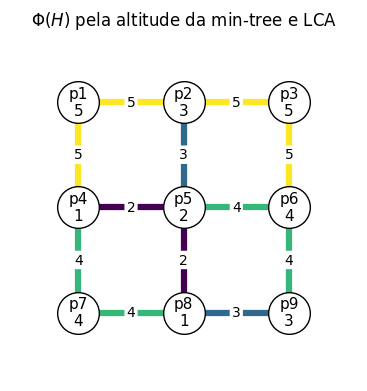

In [5]:
def lowest_common_ancestor(tree, first_node, second_node):
    ancestors = set()
    current = int(first_node)
    while True:
        ancestors.add(current)
        parent = int(tree.getNodeParent(current))
        if parent == current:
            break
        current = parent

    current = int(second_node)
    while current not in ancestors:
        current = int(tree.getNodeParent(current))
    return current


mmcfilters.HierarchySaliencyMapValidation.validateHierarchyValuation(
    min_tree,
    min_altitude,
    nonnegative=True,
)

lca_edge_map = mmcfilters.HierarchySaliencyMap.computeSaliencyEdgeMap(
    min_tree,
    min_altitude,
)
appearance_levels = (
    mmcfilters.ComponentTreePartitionHierarchyAdapter
    .computePartitionAppearanceLevels(min_tree)
)
appearance_edge_map = (
    mmcfilters.ComponentTreePartitionHierarchyAdapter
    .computeSaliencyEdgeMap(
        min_tree,
        appearance_levels,
        strict=True,
    )
)

lca_values = edge_lookup(lca_edge_map)
appearance_values = edge_lookup(appearance_edge_map)
lca_rows = []
for source, target in graph_edges:
    source_owner = int(min_tree.getProperPartOwner(source))
    target_owner = int(min_tree.getProperPartOwner(target))
    lca_node = lowest_common_ancestor(min_tree, source_owner, target_owner)
    pair = tuple(sorted((source, target)))
    lca_rows.append(
        {
            "aresta": f"{pixel_name(source)}—{pixel_name(target)}",
            "owner(p)": source_owner,
            "owner(q)": target_owner,
            "LCA": lca_node,
            "v(LCA)": int(min_altitude[lca_node]),
            "direct map": lca_values[pair],
            "level(LCA)-1": appearance_values[pair],
        }
    )

display(pd.DataFrame(lca_rows))
plot_edge_values(
    image,
    graph_edges,
    [lca_values[tuple(sorted(edge))] for edge in graph_edges],
    r"$\Phi(H)$ using min-tree altitude and LCA",
)


## 3. Route B — MST $\rightarrow$ path maximum

Starting from graph weights $w$, select a minimum spanning tree $T$ and define

\[
S_T(p,q)=\max_{e\in\operatorname{path}_T(p,q)}w(e).
\]

The MST minimax property recovers the level at which endpoints become connected in the QFZ hierarchy.

,aresta,w original,in MST,maximum no caminho MST,LCA saliency,caminho
0,p1—p2,5,True,5,5.0,p1—p2[5]
1,p1—p4,5,False,5,5.0,p1—p2[5] → p2—p5[3] → p5—p4[2]
2,p2—p3,5,True,5,5.0,p2—p3[5]
3,p2—p5,3,True,3,3.0,p2—p5[3]
4,p3—p6,5,False,5,5.0,p3—p2[5] → p2—p5[3] → p5—p6[4]
5,p4—p5,2,True,2,2.0,p4—p5[2]
6,p4—p7,4,True,4,4.0,p4—p7[4]
7,p5—p6,4,True,4,4.0,p5—p6[4]
8,p5—p8,2,True,2,2.0,p5—p8[2]
9,p6—p9,4,False,4,4.0,p6—p5[4] → p5—p8[2] → p8—p9[3]


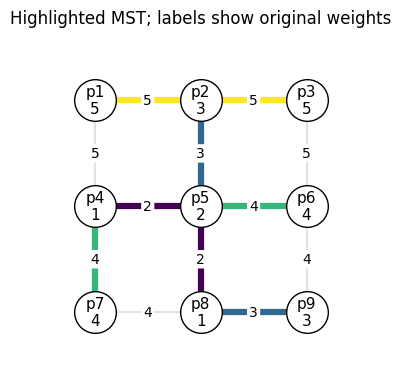

In [6]:
weighted_edges = [
    (source, target, int(weight))
    for (source, target), weight in zip(graph_edges, edge_weights)
]

kruskal_components = DisjointSet(image.size)
mst_edges = []
for source, target, weight in sorted(
    weighted_edges,
    key=lambda edge: (edge[2], edge[0], edge[1]),
):
    if kruskal_components.unite(source, target):
        mst_edges.append((source, target, weight))

mst_adjacency = {pixel_id: [] for pixel_id in range(image.size)}
for source, target, weight in mst_edges:
    mst_adjacency[source].append((target, weight))
    mst_adjacency[target].append((source, weight))


def mst_path_maximum(source, target):
    stack = [(source, -1, 0, [])]
    while stack:
        current, parent, maximum, path = stack.pop()
        if current == target:
            return maximum, path
        for neighbor, weight in mst_adjacency[current]:
            if neighbor != parent:
                stack.append(
                    (
                        neighbor,
                        current,
                        max(maximum, weight),
                        path + [(current, neighbor, weight)],
                    )
                )
    raise RuntimeError("The MST must connect every pixel.")


mst_pairs = {
    tuple(sorted((source, target)))
    for source, target, _weight in mst_edges
}
mst_comparison_rows = []
for (source, target), original_weight in zip(graph_edges, edge_weights):
    maximum, path = mst_path_maximum(source, target)
    pair = tuple(sorted((source, target)))
    mst_comparison_rows.append(
        {
            "aresta": f"{pixel_name(source)}—{pixel_name(target)}",
            "w original": original_weight,
            "in MST": pair in mst_pairs,
            "maximum no caminho MST": maximum,
            "LCA saliency": lca_values[pair],
            "caminho": " → ".join(
                f"{pixel_name(first)}—{pixel_name(second)}[{weight}]"
                for first, second, weight in path
            ),
        }
    )

mst_comparison_frame = pd.DataFrame(mst_comparison_rows)
display(mst_comparison_frame)
plot_edge_values(
    image,
    graph_edges,
    edge_weights,
    "Highlighted MST; labels show original weights",
    emphasized=mst_pairs,
)


### 3.1 Is an MST always required?

No. When a hierarchy and compatible valuation already exist, direct LCA projection is sufficient. An MST is useful for arbitrary edge weights, efficient QFZ construction, and persistence at hierarchical-watershed merge events. The formal extinction API later in this notebook builds an MST/BPTAO internally.

For this example, $\Phi(H)(p,q)$ equals the maximum edge weight on the MST path for all twelve grid edges.

## 4. Which valuations are valid?

The essential condition is `v(parent) >= v(child)`. Altitude is not mandatory; area, structural levels, or another increasing valuation may be used.

Raw min-tree altitude satisfies the condition. Raw max-tree altitude has the opposite orientation and is rejected; use a transformed valuation or `computeNormalizedAltitudeEdgeMap`.

In [7]:
max_tree = mmcfilters.MorphologicalTreeFactory.createMaxTree(
    image,
    radius=1.0,
)
max_altitude = np.zeros(max_tree.numInternalNodeSlots, dtype=np.float32)
for node_id in max_tree.getAliveNodeIds():
    node_id = int(node_id)
    max_altitude[node_id] = float(max_tree.getAltitude(node_id))

valuation_checks = []
for name, tree, valuation in [
    ("min-tree altitude", min_tree, min_altitude),
    ("raw max-tree altitude", max_tree, max_altitude),
]:
    try:
        mmcfilters.HierarchySaliencyMapValidation.validateHierarchyValuation(
            tree,
            valuation,
            nonnegative=True,
        )
        valuation_checks.append({"valuation": name, "valid": True, "message": "accepted"})
    except ValueError as error:
        valuation_checks.append({"valuation": name, "valid": False, "message": str(error)})

display(pd.DataFrame(valuation_checks))

normalized_max_map = (
    mmcfilters.HierarchySaliencyMap.computeNormalizedAltitudeEdgeMap(max_tree)
)
normalized_max_values = np.asarray(normalized_max_map["values"])
print(
    "normalized max-tree altitude:",
    f"intervalo [{normalized_max_values.min():.3f}, {normalized_max_values.max():.3f}]",
)


,valuation,valid,message
0,min-tree altitude,True,accepted
1,raw max-tree altitude,False,HierarchySaliencyMapValidation.validateHierarc...


normalized max-tree altitude: range [0.250, 1.000]


## 5. Extinction and hierarchical watershed

The example min-tree has two minima, so area extinction has one dominant and one finite record. `computeFormalSaliencyEdgeMap` does not directly project the max-descendant valuation. It builds an altitude-ordered MST, forms the Kruskal BPTAO, assigns persistence from leaf extinctions, and extends the resulting QFZ dendrogram to the original graph.

,leaf,cutoff,area extinction,dominant
0,4,0,NaN,True
1,5,5,1.0,False


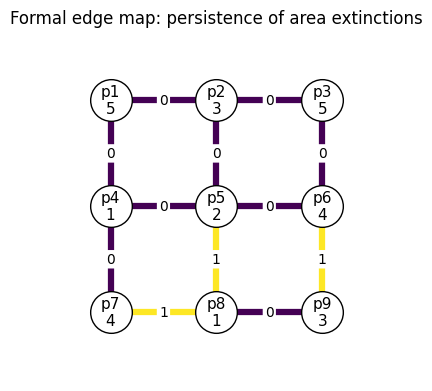

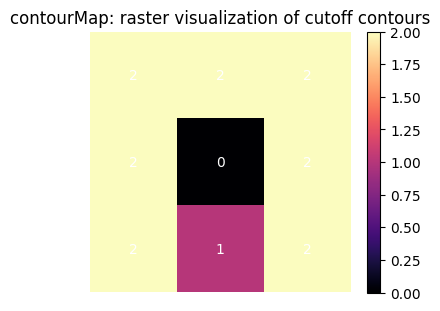

In [8]:
min_area = np.ascontiguousarray(
    mmcfilters.Attribute.computeSingleTopologyAttribute(
        min_tree,
        mmcfilters.Attribute.AREA,
    ),
    dtype=np.float32,
)
area_extinction = mmcfilters.ExtinctionValues(min_tree, min_area)
float32_max = np.finfo(np.float32).max

extinction_rows = []
for leaf_id, cutoff_node_id, extinction in area_extinction.getRegionalExtrema():
    dominant = float(extinction) >= float32_max
    extinction_rows.append(
        {
            "leaf": int(leaf_id),
            "cutoff": int(cutoff_node_id),
            "area extinction": np.nan if dominant else float(extinction),
            "dominant": dominant,
        }
    )
display(pd.DataFrame(extinction_rows))

formal_extinction_map = area_extinction.computeFormalSaliencyEdgeMap(
    ranked=True,
)
formal_extinction_values = edge_lookup(formal_extinction_map)

selection = mmcfilters.ExtinctionSelectionPolicy.byTopK(
    int(min_tree.numLeafNodes)
)
contour_raster = area_extinction.contourMap(
    selection,
    mmcfilters.ExtinctionContourScorePolicy.RankScore,
)

plot_edge_values(
    image,
    graph_edges,
    [formal_extinction_values[tuple(sorted(edge))] for edge in graph_edges],
    "Formal edge map: persistence of area extinctions",
)

fig, axis = plt.subplots(figsize=(5, 3), constrained_layout=True)
artist = axis.imshow(contour_raster, cmap="magma", interpolation="nearest")
for pixel_id, value in enumerate(contour_raster.ravel()):
    row, col = divmod(pixel_id, num_cols)
    axis.text(col, row, f"{value:g}", ha="center", va="center", color="white")
axis.set_title("contourMap: raster visualization of cutoff contours")
axis.axis("off")
fig.colorbar(artist, ax=axis, fraction=0.046, pad=0.04)
plt.show()


### 5.1 Why are the displayed results different?

- `computeFormalSaliencyEdgeMap` returns the formal edge arrays.
- `contourMap` returns an image-shaped raster of selected cutoff contours.
- `edgeMapToPixelImage` rasterizes an already computed formal edge map.

An image-shaped matrix is not automatically a formal hierarchy saliency map.

## 6. Circularity and shape space

Circularity is generally not increasing on the original tree. Passing it directly to `computeSaliencyEdgeMap` violates the hierarchy contract.

Shape space changes the object: original nodes become graph vertices, parent-child relations become edges, and a second component hierarchy is formed over circularity. Extinction is computed there and projected by maximum on original contours—not by LCA on the first tree.

,node,parent,circularity
0,0,0,1.000000
1,1,0,0.857143
2,2,1,0.380487
3,3,2,0.333333
4,4,3,1.000000
5,5,3,1.000000


circularity valid on min-tree? False
HierarchySaliencyMapValidation.validateHierarchyValuation requires valuation(parent) >= valuation(child); parent node 3 has value 0.333333 and child node 4 has value 1.


,representative,birthLevel,deathLevel,extinction
0,0,1.0,0.333333,0.666667
1,4,1.0,0.333333,0.666667
2,5,1.0,0.333333,0.666667


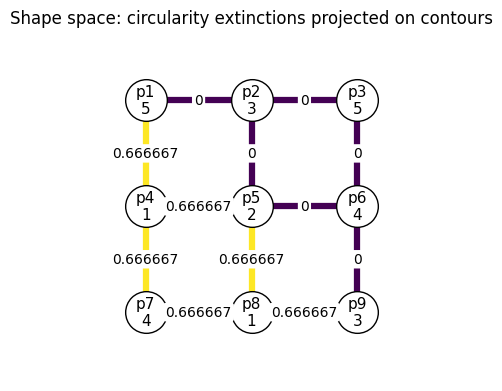

In [9]:
circularity = np.ascontiguousarray(
    mmcfilters.Attribute.computeSingleTopologyAttribute(
        min_tree,
        mmcfilters.Attribute.CIRCULARITY,
    ),
    dtype=np.float32,
)

circularity_is_valid = True
circularity_validation_message = "accepted"
try:
    mmcfilters.HierarchySaliencyMapValidation.validateHierarchyValuation(
        min_tree,
        circularity,
        nonnegative=True,
    )
except ValueError as error:
    circularity_is_valid = False
    circularity_validation_message = str(error)

circularity_rows = []
for node_id in min_tree.getAliveNodeIds():
    node_id = int(node_id)
    circularity_rows.append(
        {
            "node": node_id,
            "parent": int(min_tree.getNodeParent(node_id)),
            "circularity": float(circularity[node_id]),
        }
    )
display(pd.DataFrame(circularity_rows))
print("circularity valid on min-tree?", circularity_is_valid)
print(circularity_validation_message)

shape_space_result = mmcfilters.ShapeSpaceSaliency.compute(
    min_tree,
    circularity,
    mmcfilters.ShapeSpaceExtremaPolarity.Maxima,
)
display(pd.DataFrame(shape_space_result["extrema"]))

shape_edge_values = edge_lookup(shape_space_result["edgeMap"])
plot_edge_values(
    image,
    graph_edges,
    [shape_edge_values[tuple(sorted(edge))] for edge in graph_edges],
    "Shape space: circularity extinctions projected on contours",
)


### 6.1 Alternatives without materializing a shape-space tree

1. **Implicit persistence:** union-find sweeps circularity on the parent-child graph and computes births/deaths without storing the second tree; the mathematics remains shape-space persistence.
2. **Filter the original hierarchy:** use circularity to select nodes, contract rejected nodes, and assign rootward-increasing ranks. The resulting LCA map is saliency of a circularity-filtered hierarchy, not circularity extinction.

`SimpleExamples.ipynb` contains executable variants.

## 7. API selection

| Goal | Main API | Explicit MST? | Interpretation |
| --- | --- | ---: | --- |
| project a compatible hierarchy valuation | `computeSaliencyEdgeMap` | no | LCA `Phi(H)` |
| use canonical structural levels | `computeTopologicalLevelEdgeMap` | no | hierarchy structure |
| use oriented max/min altitude in `[0,1]` | `computeNormalizedAltitudeEdgeMap` | no | rootward altitude |
| build an extinction hierarchical watershed | `computeFormalSaliencyEdgeMap` | internal | MST/BPTAO persistence |
| preserve former extinction projection | `computeMonotoneExtinctionProjection` | no | max-descendant valuation + LCA |
| draw cutoff contours | `contourMap` | no | raster visualization |
| use a non-monotone attribute | `ShapeSpaceSaliency.compute` | second hierarchy | shape-space extinction + maximum on contours |
| display an edge map as an image | `edgeMapToPixelImage` | no | visualization only |

## 8. Reproducible checks

The assertions record the example's central invariants. A semantic implementation change will fail the notebook instead of silently preserving an obsolete conclusion.

In [10]:
expected_saliency = {
    tuple(sorted(edge)): float(weight)
    for edge, weight in zip(graph_edges, edge_weights)
}

assert image.shape == (3, 3)
assert len(graph_edges) == 12
assert min_tree.numLeafNodes == 2
assert max_tree.numLeafNodes == 3

for edge in graph_edges:
    pair = tuple(sorted(edge))
    mst_maximum, _path = mst_path_maximum(*edge)
    assert lca_values[pair] == expected_saliency[pair]
    assert mst_maximum == expected_saliency[pair]

assert not circularity_is_valid
assert set(("sources", "targets", "values")).issubset(formal_extinction_map)
assert np.asarray(formal_extinction_map["values"]).size == len(graph_edges)
assert contour_raster.shape == image.shape

cut_low = mmcfilters.HierarchySaliencyMapProjection.thresholdCut(
    lca_edge_map,
    threshold=3.0,
)
cut_high = mmcfilters.HierarchySaliencyMapProjection.thresholdCut(
    lca_edge_map,
    threshold=5.0,
)
assert len(cut_high["sources"]) <= len(cut_low["sources"])

print("✓ min-tree + LCA matches all twelve expected weights")
print("✓ MST path maximum matches min-tree + LCA")
print("✓ raw circularity is rejected as a min-tree valuation")
print("✓ the formal map is edge-indexed; contourMap is a 3x3 matrix")
print("✓ higher-threshold cuts keep no more edges")


✓ min-tree + LCA matches all twelve expected weights
✓ MST path maximum matches min-tree + LCA
✓ raw circularity is rejected as a min-tree valuation
✓ the formal map is edge-indexed; contourMap is a 3x3 matrix
✓ higher-threshold cuts keep no more edges


## Conclusions

1. Cousty's formal saliency map is graph-edge indexed.
2. An existing connected hierarchy can be projected directly by LCA.
3. From edge weights, an MST compactly represents the QFZ hierarchy and path maxima recover saliency.
4. Persistence, direct LCA projection, cutoff-contour visualization, and shape space are related but not interchangeable.
5. Raw circularity must not be treated as an increasing valuation without validation or an explicit hierarchy transform.

### Complexity

For $m$ tree nodes, $p$ proper parts, and $e$ graph edges, connectivity validation and direct projection have linear terms in $m+p+e$. The Cousty persistence path costs $O(e\log e+p\log p)$ plus linear validation/projection terms. See the canonical guide for memory bounds.

### Reading

- [Canonical saliency guide](../docs/saliency.md)
- [Tree-facing API](../docs/trees.md#hierarchy-edge-saliency)
- [Python API](../docs/python-api.md#hierarchy-edge-saliency)
- [Release notes](../CHANGELOG.md)